# Task 2: Multi-Modal Cardiac Image Fusion

This notebook fuses a CT slice and its corresponding MRI slice of the
heart into a single, unified diagnostic view. The pipeline includes
histogram equalization, color mapping, weighted fusion, and
logarithmic/power-law post-processing.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output directory
os.makedirs('output', exist_ok=True)

## 1. Load Modalities
Load one CT slice and its perfectly corresponding MRI slice from the
dataset. Both are loaded as grayscale images.

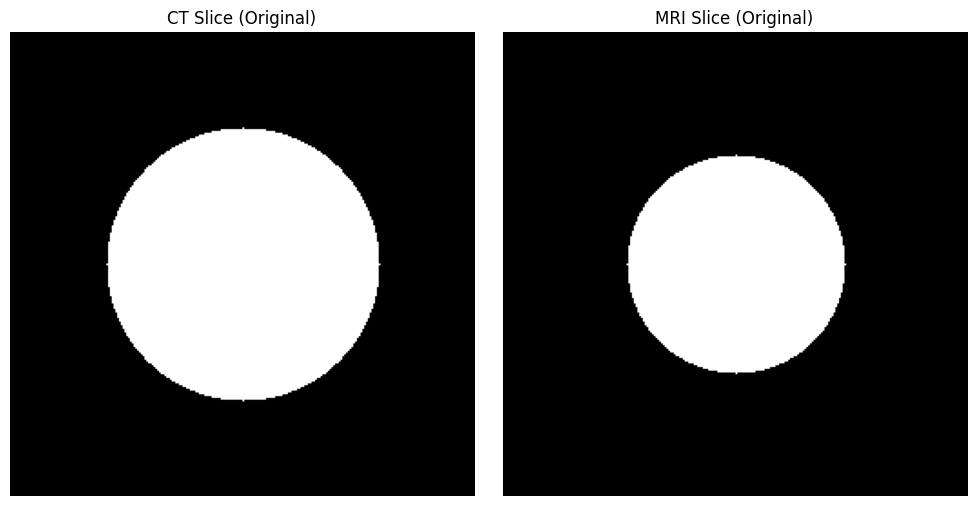

CT  shape: (256, 256), range: [0, 174]
MRI shape: (256, 256), range: [0, 144]


In [3]:
ct_img = cv2.imread('data/sample_ct.png', cv2.IMREAD_GRAYSCALE)
mri_img = cv2.imread('data/sample_mri.png', cv2.IMREAD_GRAYSCALE)

if ct_img is None:
    raise FileNotFoundError("Could not load data/sample_ct.png")
if mri_img is None:
    raise FileNotFoundError("Could not load data/sample_mri.png")

# Ensure both images have the same dimensions
if ct_img.shape != mri_img.shape:
    mri_img = cv2.resize(mri_img, (ct_img.shape[1], ct_img.shape[0]))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(ct_img, cmap='gray')
axes[0].set_title('CT Slice (Original)')
axes[0].axis('off')
axes[1].imshow(mri_img, cmap='gray')
axes[1].set_title('MRI Slice (Original)')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/01_original_modalities.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"CT  shape: {ct_img.shape}, range: [{ct_img.min()}, {ct_img.max()}]")
print(f"MRI shape: {mri_img.shape}, range: [{mri_img.min()}, {mri_img.max()}]")

## 2. Histogram Equalization
Apply equalization to both the CT and MRI matrices independently to
maximize their dynamic ranges before blending.

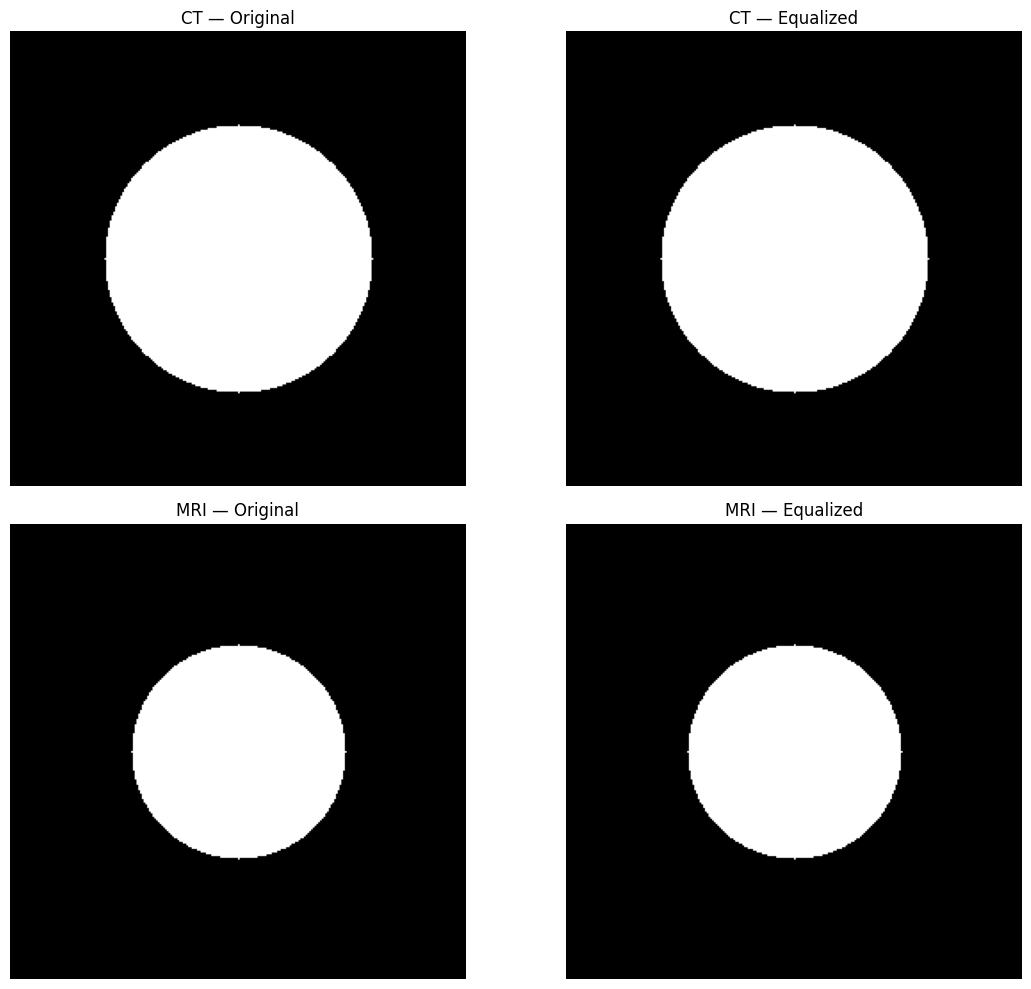

In [4]:
ct_eq = cv2.equalizeHist(ct_img)
mri_eq = cv2.equalizeHist(mri_img)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(ct_img, cmap='gray')
axes[0, 0].set_title('CT — Original')
axes[0, 0].axis('off')
axes[0, 1].imshow(ct_eq, cmap='gray')
axes[0, 1].set_title('CT — Equalized')
axes[0, 1].axis('off')
axes[1, 0].imshow(mri_img, cmap='gray')
axes[1, 0].set_title('MRI — Original')
axes[1, 0].axis('off')
axes[1, 1].imshow(mri_eq, cmap='gray')
axes[1, 1].set_title('MRI — Equalized')
axes[1, 1].axis('off')
plt.tight_layout()
plt.savefig('output/02_equalized.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Color Mapping and Fusion
Convert the enhanced CT and MRI images into colored heatmaps using
different color maps (CT → HOT for structural edges, MRI → COOL/BONE
for soft tissue). Then overlay the matrices to create a unified view.

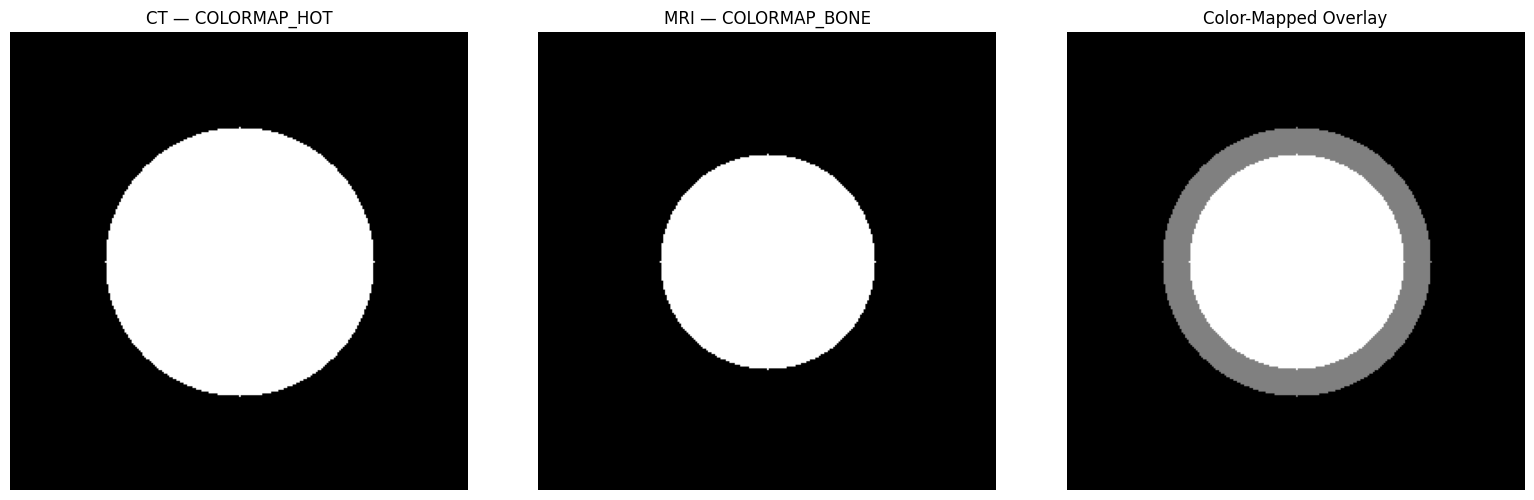

In [5]:
ct_color = cv2.applyColorMap(ct_eq, cv2.COLORMAP_HOT)
ct_color_rgb = cv2.cvtColor(ct_color, cv2.COLOR_BGR2RGB)

mri_color = cv2.applyColorMap(mri_eq, cv2.COLORMAP_BONE)
mri_color_rgb = cv2.cvtColor(mri_color, cv2.COLOR_BGR2RGB)

# Simple overlay (average)
overlay = cv2.addWeighted(ct_color, 0.5, mri_color, 0.5, 0)
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(ct_color_rgb)
axes[0].set_title('CT — COLORMAP_HOT')
axes[0].axis('off')
axes[1].imshow(mri_color_rgb)
axes[1].set_title('MRI — COLORMAP_BONE')
axes[1].axis('off')
axes[2].imshow(overlay_rgb)
axes[2].set_title('Color-Mapped Overlay')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('output/03_color_mapped.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Multi-Modal Weighted Fusion
Use `cv2.addWeighted()` to adjust the alpha and beta blending values.
A heavier weight is assigned to the CT matrix to preserve sharp
anatomical edges, and a lighter weight to the MRI matrix to highlight
internal tissue variations.

**Weights:** CT α = 0.7 (structural priority) | MRI β = 0.3 (soft tissue)

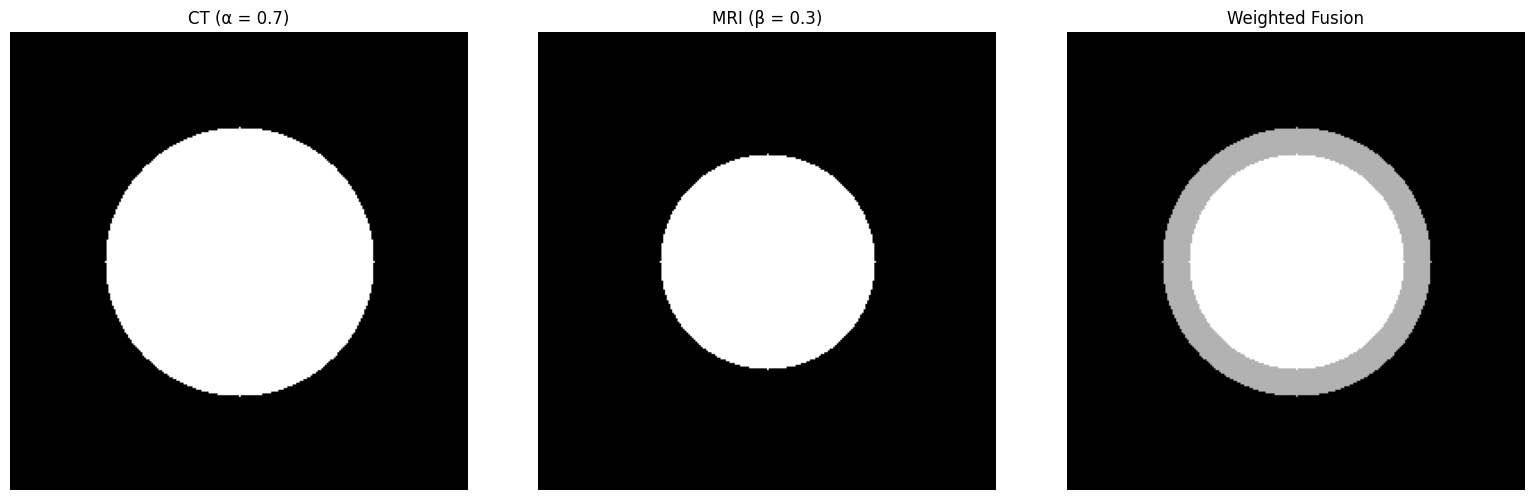

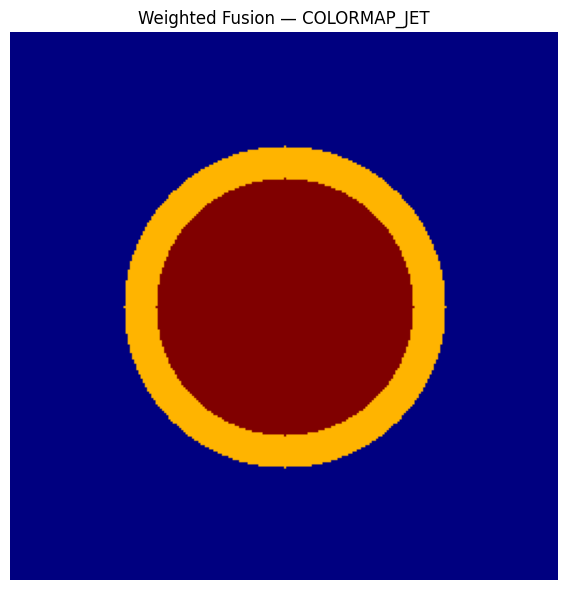

In [6]:
alpha = 0.7   # CT weight — preserves sharp anatomical edges
beta  = 0.3   # MRI weight — highlights soft tissue variations
gamma_val = 0  # brightness offset

fused = cv2.addWeighted(ct_eq, alpha, mri_eq, beta, gamma_val)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(ct_eq, cmap='gray')
axes[0].set_title(f'CT (α = {alpha})')
axes[0].axis('off')
axes[1].imshow(mri_eq, cmap='gray')
axes[1].set_title(f'MRI (β = {beta})')
axes[1].axis('off')
axes[2].imshow(fused, cmap='gray')
axes[2].set_title('Weighted Fusion')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('output/04_weighted_fusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Also create a colored version of the fused result
fused_color = cv2.applyColorMap(fused, cv2.COLORMAP_JET)
fused_color_rgb = cv2.cvtColor(fused_color, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(fused_color_rgb)
plt.title('Weighted Fusion — COLORMAP_JET')
plt.axis('off')
plt.tight_layout()
plt.savefig('output/04_weighted_fusion_jet.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Logarithmic and Power-Law Transformations
Pass the final fused matrix through logarithmic and power-law functions
to ensure no critical data is crushed into pure black or blown out to
pure white during the addition process.

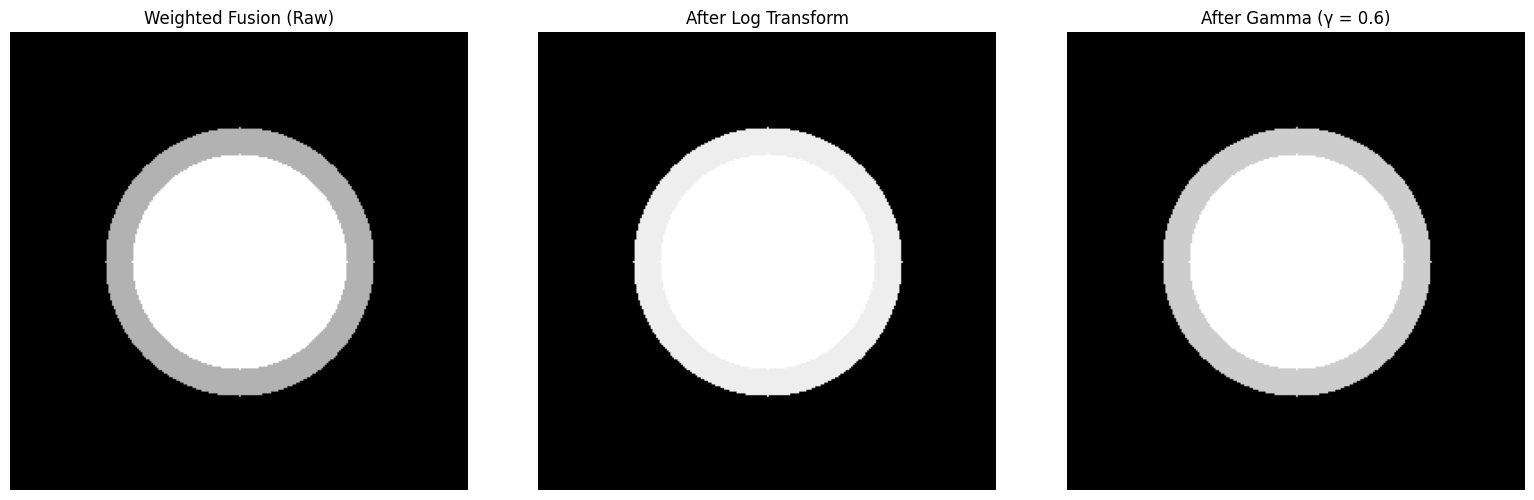

In [7]:
fused_float = fused.astype(np.float64)
c = 255.0 / np.log(1 + fused_float.max())
fused_log = c * np.log(1 + fused_float)
fused_log = np.clip(fused_log, 0, 255).astype(np.uint8)

# Power-Law (Gamma) Transformation on Fused Image
gamma = 0.6
fused_normalized = fused.astype(np.float64) / 255.0
fused_gamma = np.power(fused_normalized, gamma)
fused_gamma = (fused_gamma * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(fused, cmap='gray')
axes[0].set_title('Weighted Fusion (Raw)')
axes[0].axis('off')
axes[1].imshow(fused_log, cmap='gray')
axes[1].set_title('After Log Transform')
axes[1].axis('off')
axes[2].imshow(fused_gamma, cmap='gray')
axes[2].set_title(f'After Gamma (γ = {gamma})')
axes[2].axis('off')
plt.tight_layout()
plt.savefig('output/05_log_gamma_fusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Comparative Analysis
Display the standalone CT frame, the standalone MRI frame, and the fused
output side-by-side to visually validate the success of the fusion.

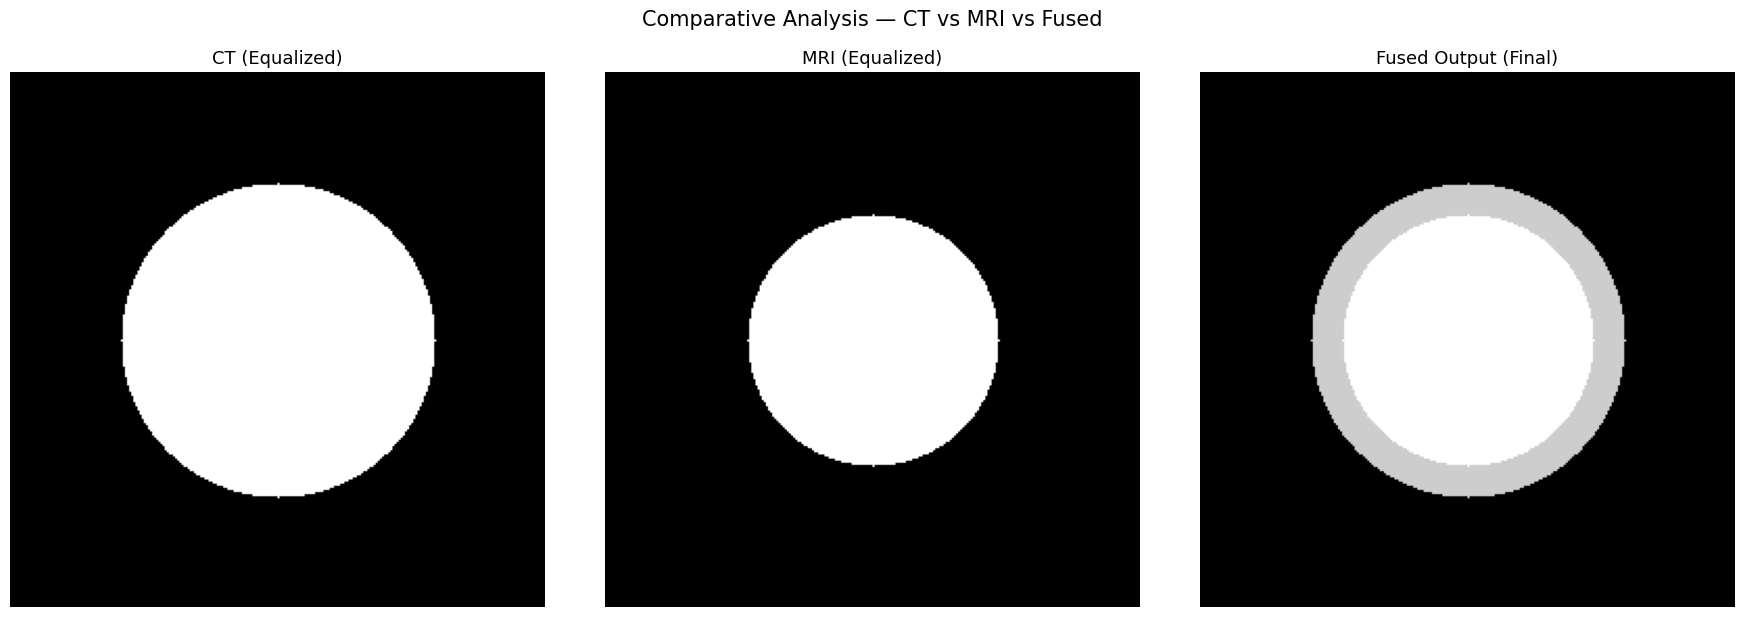

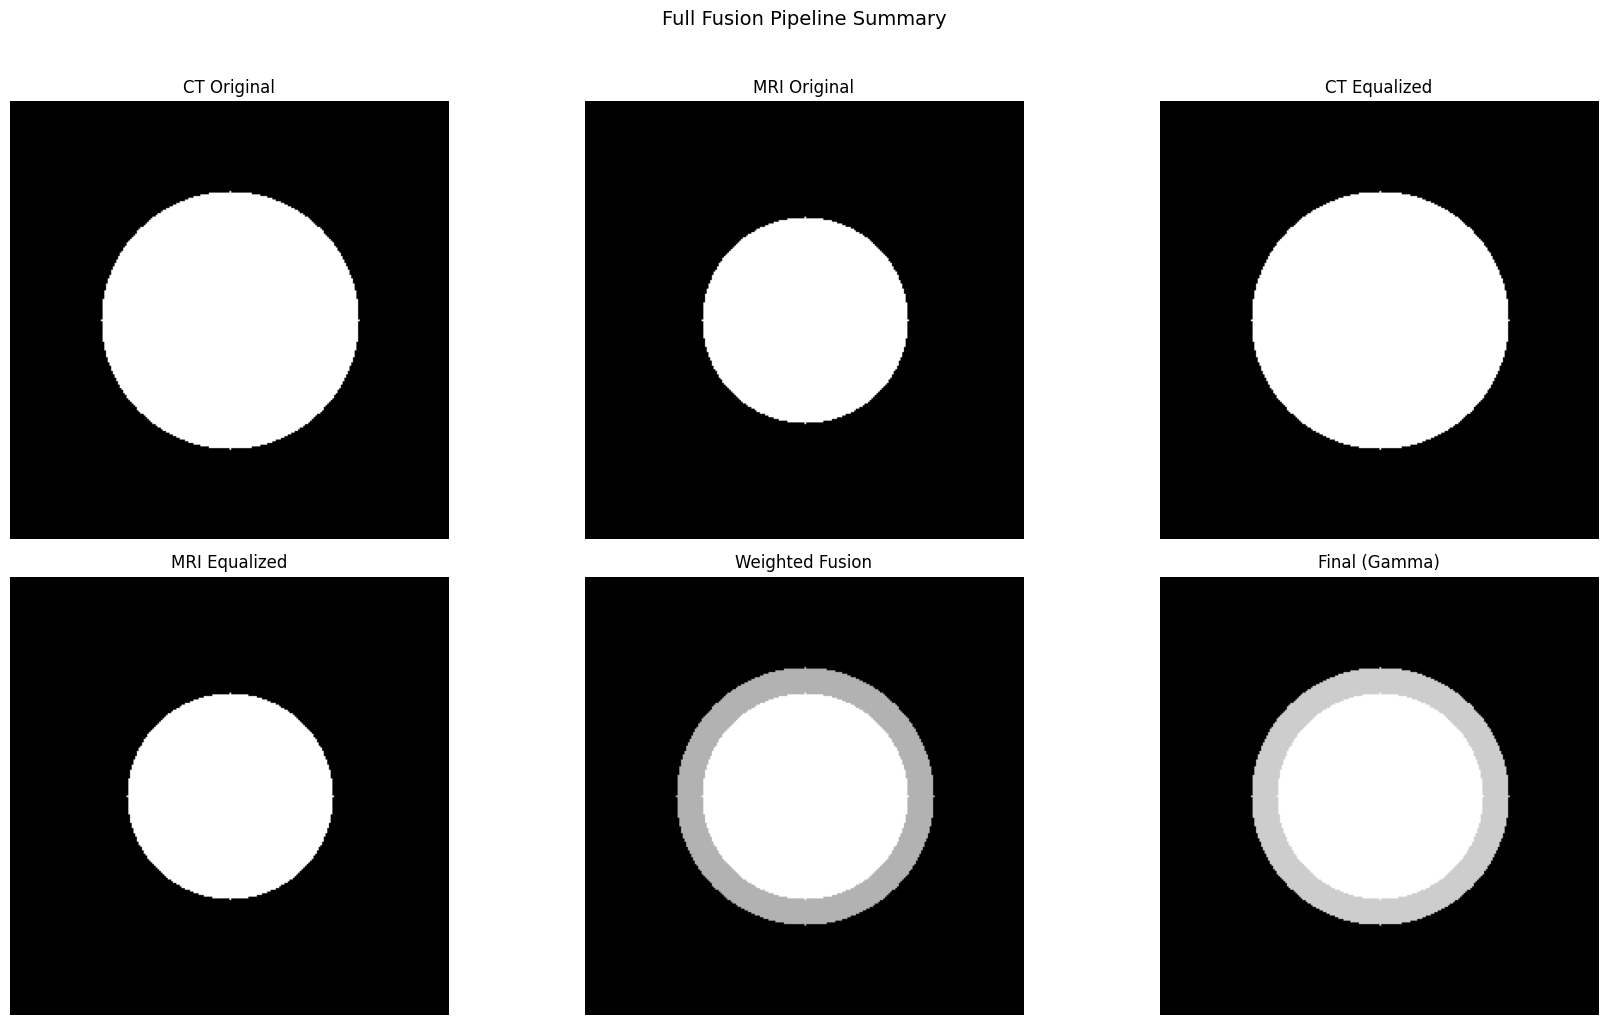

All output images saved to output/ directory.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(ct_eq, cmap='gray')
axes[0].set_title('CT (Equalized)', fontsize=13)
axes[0].axis('off')
axes[1].imshow(mri_eq, cmap='gray')
axes[1].set_title('MRI (Equalized)', fontsize=13)
axes[1].axis('off')
axes[2].imshow(fused_gamma, cmap='gray')
axes[2].set_title('Fused Output (Final)', fontsize=13)
axes[2].axis('off')
plt.suptitle('Comparative Analysis — CT vs MRI vs Fused', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('output/06_comparative.png', dpi=150, bbox_inches='tight')
plt.show()

# Full summary grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
titles_row1 = ['CT Original', 'MRI Original', 'CT Equalized']
imgs_row1   = [ct_img, mri_img, ct_eq]
titles_row2 = ['MRI Equalized', 'Weighted Fusion', 'Final (Gamma)']
imgs_row2   = [mri_eq, fused, fused_gamma]

for ax, image, title in zip(axes[0], imgs_row1, titles_row1):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
for ax, image, title in zip(axes[1], imgs_row2, titles_row2):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.suptitle('Full Fusion Pipeline Summary', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output/07_full_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("All output images saved to output/ directory.")